In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Conv2D, AveragePooling2D, Flatten
from keras import Sequential
from keras.datasets import mnist


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

# LeNet 5

In [4]:
model = Sequential()
model.add(Conv2D(6,kernel_size=(5,5), padding='valid', activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2 ,padding='valid'))
model.add(Conv2D(16,kernel_size=(5,5), padding='valid', activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2,padding='valid'))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))



In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 6)         156       
                                                                 
 average_pooling2d (AverageP  (None, 12, 12, 6)        0         
 ooling2D)                                                       
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 16)          2416      
                                                                 
 average_pooling2d_1 (Averag  (None, 4, 4, 16)         0         
 ePooling2D)                                                     
                                                                 
 flatten (Flatten)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 120)               3

In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [7]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 [==============================] - 23s 7ms/step - loss: 0.1592 - accuracy: 0.9523 - val_loss: 0.0682 - val_accuracy: 0.9785
Epoch 2/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0636 - accuracy: 0.9808 - val_loss: 0.0499 - val_accuracy: 0.9834
Epoch 3/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.0486 - accuracy: 0.9847 - val_loss: 0.0492 - val_accuracy: 0.9840
Epoch 4/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.0407 - accuracy: 0.9867 - val_loss: 0.0517 - val_accuracy: 0.9831
Epoch 5/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0323 - accuracy: 0.9896 - val_loss: 0.0455 - val_accuracy: 0.9863
Epoch 6/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0294 - accuracy: 0.9909 - val_loss: 0.0449 - val_accuracy: 0.9866
Epoch 7/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0230 - accuracy: 0.9926 - val_loss: 0.0396 - val_ac

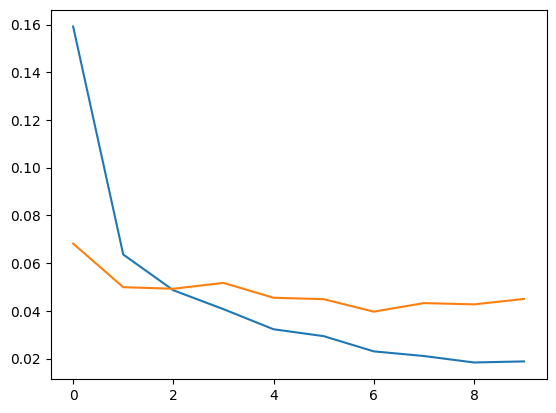

In [8]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')


C:\Users\bhara\AppData\Local\Temp\ipykernel_10028\2902555362.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


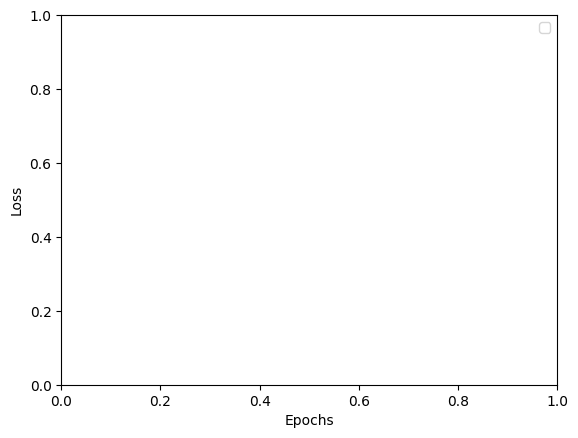

In [9]:
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

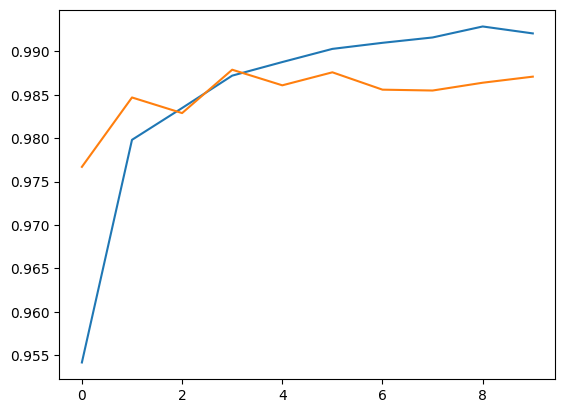

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')


In [11]:
history.history

{'loss': [0.15187393128871918,
  0.06659691780805588,
  0.050892122089862823,
  0.04125700518488884,
  0.03491091728210449,
  0.031048135831952095,
  0.027368351817131042,
  0.025305381044745445,
  0.021626397967338562,
  0.023470619693398476],
 'accuracy': [0.9541500210762024,
  0.9798166751861572,
  0.9834833145141602,
  0.9872166514396667,
  0.9887833595275879,
  0.9902999997138977,
  0.9909999966621399,
  0.9916166663169861,
  0.9928833246231079,
  0.9920833110809326],
 'val_loss': [0.07014927268028259,
  0.04913731664419174,
  0.05422329157590866,
  0.03873647004365921,
  0.039775948971509933,
  0.041911110281944275,
  0.04851234704256058,
  0.04474196583032608,
  0.044529061764478683,
  0.042724598199129105],
 'val_accuracy': [0.9767000079154968,
  0.9847000241279602,
  0.9829000234603882,
  0.9879000186920166,
  0.9861000180244446,
  0.9876000285148621,
  0.9855999946594238,
  0.9854999780654907,
  0.9864000082015991,
  0.9871000051498413]}